### Import neccessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Read and clean data

In [2]:
columns_to_read = [
    'review_id',
    'app_id',  
    'review',
    'recommended',
    'weighted_vote_score',
    'author.steamid',
    'author.playtime_forever'
]


final_df = pd.DataFrame()

# Set the chunksize
chunksize = 1000000  # Number of rows per chunk

# Read the CSV in chunks and process each chunk
file_path = 'dataset/steam_reviews.csv'  
for chunk in pd.read_csv(file_path, usecols=columns_to_read, chunksize=chunksize):
    
    # Empty review replaced with empty string
    chunk['review'] = chunk['review'].fillna(' ')
    
    # four scenarios considered to calculate the user's review score for an app
    # a user who provided review and recommended the app - assigned a weight of 7
    # a user who provided review and didn't recommend the app - assigned a weight of 2
    # a user who didn't provide both review and hasn't recommended the app - assigned a weight of 1
    # a user who didn't provide review but has recommended the app - assigned a weight of 5
    
    # the review score is calculated using the assigned weight from the above scenarios multiplied
    # by the weighted_vote_score of the individual users
    chunk['individual_review_score'] = (
        chunk['weighted_vote_score'] * 7 * (chunk['recommended'] & chunk['review']!= ' ') +
        chunk['weighted_vote_score'] * 2 * (~chunk['recommended']  & chunk['review']!= ' ') +
        chunk['weighted_vote_score'] * 5 * (chunk['recommended']  & chunk['review']== ' ') +
        chunk['weighted_vote_score'] * 1 * (~chunk['recommended']  & chunk['review']== ' ') 

    )
    
    # two rows with missing value removed
    chunk_cleaned = chunk.dropna(subset=['author.playtime_forever'])
    
    # Step 2: Append the cleaned chunk to the main DataFrame
    final_df = pd.concat([final_df, chunk_cleaned], ignore_index=True)
    
    del chunk_cleaned

   
print(f'Total rows read: {len(final_df)}')

Total rows read: 21747369


In [3]:
# # final_df['individual_review_score'].max()
# # Filter expert users with avg_review_score greater than 5
# high_rate_grouped_df = final_df[final_df['individual_review_score'] > 5]

# # Print the resulting DataFrame
# high_rate_grouped_df['individual_review_score'].max()

### 4) a)

In [4]:
# Grouped based on the steamid and the app id to get the total playtime and user's review score

grouped_df = final_df.groupby(['author.steamid', 'app_id']).agg(
    total_playtime=('author.playtime_forever', 'sum'),
    avg_review_score=('individual_review_score', 'mean'),
    weighted_vote_score=('weighted_vote_score', 'first')
).reset_index()

In [5]:
# Converted the minute represented playtime to hours

grouped_df['total_playtime_hours'] = round(grouped_df['total_playtime'] / 60, 0)


In [6]:
### there are hours spent by users with an extreme large number so to remove those with abnormal values
### we used quantiles to set an upper limit and filter out outliers

# Calculate statistics
stats = grouped_df['total_playtime_hours'].describe()
q1 = stats['25%']
q3 = stats['75%']
iqr = q3 - q1  # Interquartile range

# Identifying outliers
upper_bound = q3 + 1.5 * iqr
outliers = grouped_df[(grouped_df['total_playtime_hours'] > upper_bound)]

print("Statistics:")
print(stats)
print("\nInterquartile Range (IQR):", iqr)
print("Upper Bound for Outliers:", upper_bound)
print("\nOutliers:")
outliers

### get all that are not outliers
# filtered_df = grouped_df[(grouped_df['total_playtime_hours'] <= upper_bound)]

# filtered_df

grouped_df.drop(grouped_df[grouped_df['total_playtime_hours'] > upper_bound].index, inplace=True)



Statistics:
count    2.161201e+07
mean     2.698628e+02
std      6.256111e+02
min      0.000000e+00
25%      2.100000e+01
50%      7.300000e+01
75%      2.520000e+02
max      6.241600e+04
Name: total_playtime_hours, dtype: float64

Interquartile Range (IQR): 231.0
Upper Bound for Outliers: 598.5

Outliers:


### Relationship of the total time spent and the review score

In [7]:
grouped_df['total_playtime_hours'].max()

grouped_df.shape

(19053139, 6)

In [8]:
# grouped_df[grouped_df['avg_review_score'] > 5]['avg_review_score'].min()

In [9]:
# Here looking into the correlation coefficient of the total hours spent and the review score
# and the value indicates the relationship is weak

from scipy.stats import pearsonr
from decimal import Decimal


# Sample 50,000 rows from your dataset
sample_size = 50000
sampled_df = grouped_df.sample(n=sample_size, random_state=42)

# Calculate correlation and p-value on the sample
correlation, p_value = pearsonr(sampled_df['total_playtime_hours'], sampled_df['avg_review_score'])

print(f"Sample Correlation: {correlation}")
print(f"Sample P-value: {p_value}")


Sample Correlation: 0.01572948617171623
Sample P-value: 0.0004358791530817015


The correlation coefficient value is extremely low indicating a very weak positive relationship between total_playtime_hours and avg_review_score. This suggests that changes in total playtime have almost no effect on the average review score.


The p-value is less than the typical significant level of 0.05, indicating that this weak correlation is statistically significant.

In real world scenario eventhought this correlation is statistically significant it is very samll that it likely holds little practical significance and may not have a noticeable impact.


### 4) b)

In [10]:
### using bin to group users with different experience level of category

bins = [0, 122, 244, 366, 488, 610]  
labels = ['Novice', 'Intermediate', 'Advanced', 'Expert', 'Master']
grouped_df['experience_level'] = pd.cut(grouped_df['total_playtime_hours'], bins=bins, labels=labels, right=False)


In [11]:
### novice users 

### users with a recommendation has been assigned a weight of 4 with no review and 6 if they did provide review 
### this will be multiplied with the weighted_vote_score which is between 0 and 1 to get the individual 
### review score

### we considered higher ratings users who has recommended the app and with non-zero weighted_vote_score
### and lower ratings users who hasn't recommend the app or recommenders with zero weighted_vote_socre


novice_users = grouped_df[grouped_df['experience_level'] == 'Novice']

novice_users_high_rate= novice_users[(novice_users['avg_review_score'] > 5) & (novice_users['weighted_vote_score'] != 0)]
novice_users_low_rating = novice_users[novice_users['avg_review_score'] < 5]


print('total novice users: ', novice_users.shape[0])
print('novice users that gave high rate : ',novice_users_high_rate.shape[0])
print('novice users that gave low rate : ',novice_users_low_rating.shape[0])

# Calculate percentages
high_rate_percentage = round((novice_users_high_rate.shape[0] / novice_users.shape[0]) * 100, 0)
low_rate_percentage = round((novice_users_low_rating.shape[0] / novice_users.shape[0]) * 100, 0)

# Print percentages
print('Percentage of novice users that gave high rate:', high_rate_percentage, '%')
print('Percentage of novice users that gave low rate:', low_rate_percentage, '%')
novice_users_high_rate

total novice users:  13157898
novice users that gave high rate :  414528
novice users that gave low rate :  12743370
Percentage of novice users that gave high rate: 3.0 %
Percentage of novice users that gave low rate: 97.0 %


,author.steamid,app_id,total_playtime,avg_review_score,weighted_vote_score,total_playtime_hours,experience_level
0,76561197960265730,70,407.0,6.792244,0.754694,7.0,Novice
76,76561197960267615,391220,1150.0,5.877980,0.653109,19.0,Novice
88,76561197960267889,242920,583.0,5.050478,0.561164,10.0,Novice
188,76561197960269230,304390,2779.0,5.148415,0.572046,46.0,Novice
206,76561197960269294,429660,2080.0,7.177885,0.797543,35.0,Novice
...,...,...,...,...,...,...,...
21609698,76561199128336038,508440,1061.0,6.517688,0.724188,18.0,Novice
21610084,76561199128838199,648800,85.0,5.086956,0.565217,1.0,Novice
21610216,76561199129031064,875210,1413.0,7.087386,0.787487,24.0,Novice
21610398,76561199129276655,875210,983.0,5.250000,0.583333,16.0,Novice


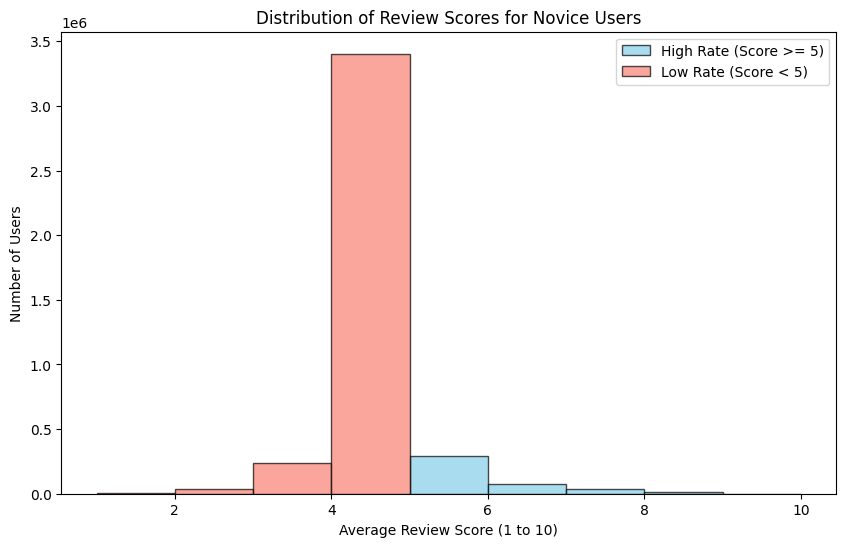

In [12]:
# Plot histograms for high and low review scores in one plot with separate bins
plt.figure(figsize=(10, 6))

# High rate scores (greater than or equal to 5)
plt.hist(novice_users_high_rate['avg_review_score'], 
         bins=[5, 6, 7, 8, 9, 10], color='skyblue', 
         alpha=0.7, label='High Rate (Score >= 5)', 
         edgecolor='black', density=False)

# Low rate scores (less than 5)
plt.hist(novice_users_low_rating['avg_review_score'], 
         bins=[1, 2, 3, 4, 5], color='salmon', 
         alpha=0.7, label='Low Rate (Score < 5)', 
         edgecolor='black', density=False)

# Add titles and labels
plt.title('Distribution of Review Scores for Novice Users')
plt.xlabel('Average Review Score (1 to 10)')
plt.ylabel('Number of Users')
plt.legend()

# Show plot
plt.show()

In [13]:

intermediate_users = grouped_df[grouped_df['experience_level'] == 'Intermediate']


intermediate_users_high_rate= intermediate_users[(intermediate_users['avg_review_score'] > 5) & (intermediate_users['weighted_vote_score'] != 0)]
intermediate_users_low_rating = intermediate_users[intermediate_users['avg_review_score'] < 5]


print('total intermediate users: ', intermediate_users.shape[0])
print('intermediate users that gave high rate : ',intermediate_users_high_rate.shape[0])
print('intermediate users that gave low rate : ',intermediate_users_low_rating.shape[0])

# Calculate percentages
high_rate_percentage = round((intermediate_users_high_rate.shape[0] / intermediate_users.shape[0]) * 100, 0)
low_rate_percentage = round((intermediate_users_low_rating.shape[0] / intermediate_users.shape[0]) * 100, 0)

# Print percentages
print('Percentage of intermediate users that gave high rate:', high_rate_percentage, '%')
print('Percentage of intermediate users that gave low rate:', low_rate_percentage, '%')
intermediate_users_high_rate

total intermediate users:  2925874
intermediate users that gave high rate :  85998
intermediate users that gave low rate :  2839876
Percentage of intermediate users that gave high rate: 3.0 %
Percentage of intermediate users that gave low rate: 97.0 %


,author.steamid,app_id,total_playtime,avg_review_score,weighted_vote_score,total_playtime_hours,experience_level
150,76561197960269034,571740,13403.0,5.644068,0.627119,223.0,Intermediate
254,76561197960269579,252490,7453.0,5.736356,0.637373,124.0,Intermediate
257,76561197960269579,275850,10346.0,5.047297,0.560811,172.0,Intermediate
415,76561197960270526,252950,9057.0,5.100000,0.566667,151.0,Intermediate
772,76561197960272169,812140,14458.0,5.130221,0.570025,241.0,Intermediate
...,...,...,...,...,...,...,...
21570157,76561199111413668,1158310,9282.0,5.575996,0.619555,155.0,Intermediate
21581041,76561199115650824,271590,10504.0,5.086956,0.565217,175.0,Intermediate
21590985,76561199121012843,346110,10957.0,5.781813,0.642424,183.0,Intermediate
21591409,76561199121187010,322330,8267.0,5.460072,0.606675,138.0,Intermediate


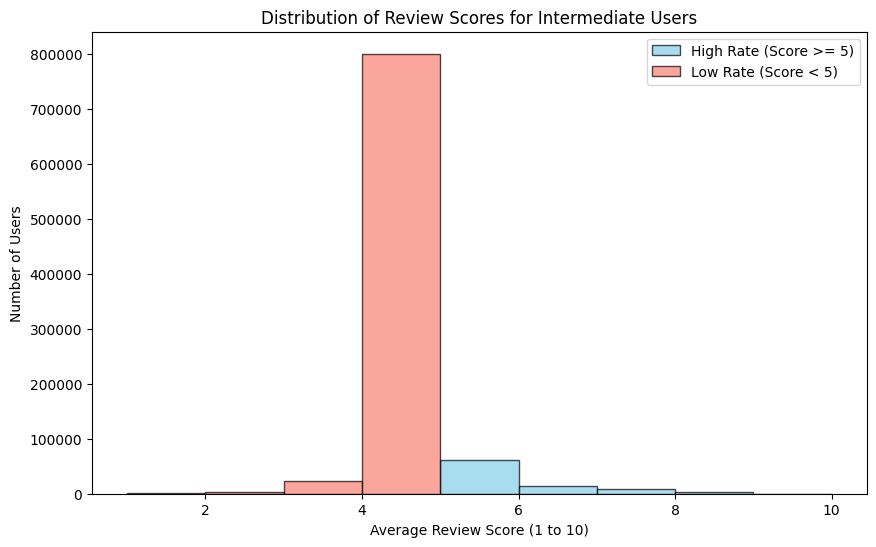

In [14]:
# Plot histograms for high and low review scores in one plot with separate bins
plt.figure(figsize=(10, 6))

# High rate scores (greater than or equal to 5)
plt.hist(intermediate_users_high_rate['avg_review_score'], 
         bins=[5, 6, 7, 8, 9, 10], color='skyblue', 
         alpha=0.7, label='High Rate (Score >= 5)', 
         edgecolor='black', density=False)

# Low rate scores (less than 5)
plt.hist(intermediate_users_low_rating['avg_review_score'], 
         bins=[1, 2, 3, 4, 5], color='salmon', 
         alpha=0.7, label='Low Rate (Score < 5)', 
         edgecolor='black', density=False)

# Add titles and labels
plt.title('Distribution of Review Scores for Intermediate Users')
plt.xlabel('Average Review Score (1 to 10)')
plt.ylabel('Number of Users')
plt.legend()

# Show plot
plt.show()

In [15]:
advanced_users = grouped_df[grouped_df['experience_level'] == 'Advanced']

advanced_users_high_rate= advanced_users[(advanced_users['avg_review_score'] > 5) & (advanced_users['weighted_vote_score'] != 0)]
advanced_users_low_rating = advanced_users[advanced_users['avg_review_score'] < 5]


print('total advanced users: ', advanced_users.shape[0])
print('advanced users that gave high rate : ',advanced_users_high_rate.shape[0])
print('advanced users that gave low rate : ',advanced_users_low_rating.shape[0])

# Calculate percentages
high_rate_percentage = round((advanced_users_high_rate.shape[0] / advanced_users.shape[0]) * 100, 0)
low_rate_percentage = round((advanced_users_low_rating.shape[0] / advanced_users.shape[0]) * 100, 0)

# Print percentages
print('Percentage of advanced users that gave high rate:', high_rate_percentage, '%')
print('Percentage of advanced users that gave low rate:', low_rate_percentage, '%')
advanced_users_high_rate

total advanced users:  1468451
advanced users that gave high rate :  42633
advanced users that gave low rate :  1425818
Percentage of advanced users that gave high rate: 3.0 %
Percentage of advanced users that gave low rate: 97.0 %


,author.steamid,app_id,total_playtime,avg_review_score,weighted_vote_score,total_playtime_hours,experience_level
465,76561197960270631,420290,15602.0,5.559787,0.617754,260.0,Advanced
467,76561197960270649,548430,21851.0,6.952165,0.772463,364.0,Advanced
1579,76561197960277727,281990,20117.0,5.140062,0.571118,335.0,Advanced
1645,76561197960278106,252490,14781.0,5.006052,0.556228,246.0,Advanced
1667,76561197960278385,218620,16722.0,5.304744,0.589416,279.0,Advanced
...,...,...,...,...,...,...,...
21544855,76561199104180529,252490,14726.0,7.010000,0.778889,245.0,Advanced
21556887,76561199107041375,613100,20203.0,6.395748,0.710639,337.0,Advanced
21569410,76561199111231671,346110,16160.0,6.361796,0.706866,269.0,Advanced
21582628,76561199116583495,644560,14636.0,7.507142,0.834127,244.0,Advanced


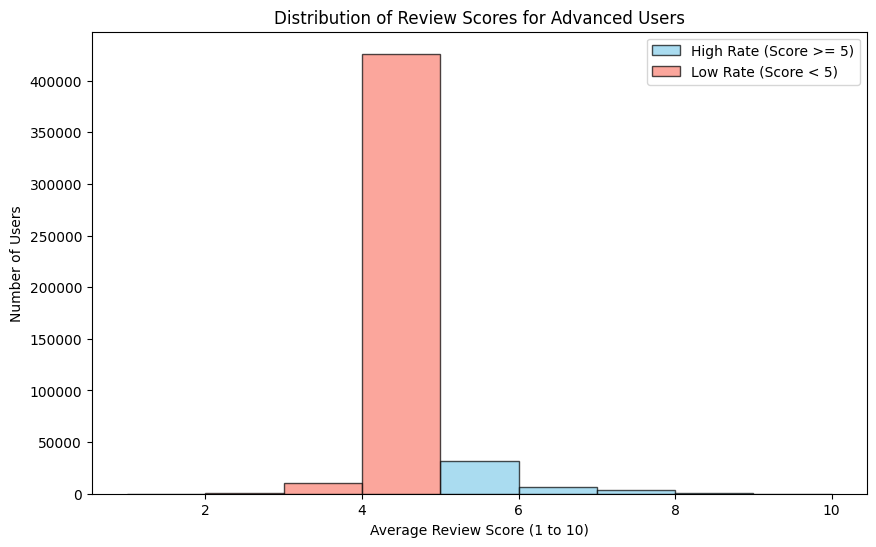

In [16]:
# Plot histograms for high and low review scores in one plot with separate bins
plt.figure(figsize=(10, 6))

# High rate scores (greater than or equal to 5)
plt.hist(advanced_users_high_rate['avg_review_score'], 
         bins=[5, 6, 7, 8, 9, 10], color='skyblue', 
         alpha=0.7, label='High Rate (Score >= 5)', 
         edgecolor='black', density=False)

# Low rate scores (less than 5)
plt.hist(advanced_users_low_rating['avg_review_score'], 
         bins=[1, 2, 3, 4, 5], color='salmon', 
         alpha=0.7, label='Low Rate (Score < 5)', 
         edgecolor='black', density=False)

# Add titles and labels
plt.title('Distribution of Review Scores for Advanced Users')
plt.xlabel('Average Review Score (1 to 10)')
plt.ylabel('Number of Users')
plt.legend()

# Show plot
plt.show()

In [17]:
expert_users = grouped_df[grouped_df['experience_level'] == 'Expert']

expert_users_high_rate= expert_users[(expert_users['avg_review_score'] > 5)  & (expert_users['weighted_vote_score'] != 0)]
expert_users_low_rating = expert_users[expert_users['avg_review_score'] < 5]


print('total expert users: ', expert_users.shape[0])
print('expert users that gave high rate : ',expert_users_high_rate.shape[0])
print('expert users that gave low rate : ',expert_users_low_rating.shape[0])

# Calculate percentages
high_rate_percentage = round((expert_users_high_rate.shape[0] / expert_users.shape[0]) * 100, 0)
low_rate_percentage = round((expert_users_low_rating.shape[0] / expert_users.shape[0]) * 100, 0)

# Print percentages
print('Percentage of expert users that gave high rate:', high_rate_percentage, '%')
print('Percentage of expert users that gave low rate:', low_rate_percentage, '%')
expert_users_high_rate

total expert users:  916367
expert users that gave high rate :  26681
expert users that gave low rate :  889686
Percentage of expert users that gave high rate: 3.0 %
Percentage of expert users that gave low rate: 97.0 %


,author.steamid,app_id,total_playtime,avg_review_score,weighted_vote_score,total_playtime_hours,experience_level
1820,76561197960279927,4000,23320.0,7.990390,0.887821,389.0,Expert
3752,76561197960296929,233860,25573.0,7.354055,0.817117,426.0,Expert
4299,76561197960302388,578080,21947.0,5.101670,0.566852,366.0,Expert
4362,76561197960303386,594650,28202.0,5.102362,0.566929,470.0,Expert
4817,76561197960308557,218620,27425.0,5.320464,0.591163,457.0,Expert
...,...,...,...,...,...,...,...
21489811,76561199095023914,552500,27716.0,5.410876,0.601208,462.0,Expert
21494758,76561199095649419,517630,29236.0,5.535231,0.615026,487.0,Expert
21503743,76561199096943546,227300,28118.0,5.015625,0.557292,469.0,Expert
21516913,76561199099172612,508440,25190.0,7.777917,0.864213,420.0,Expert


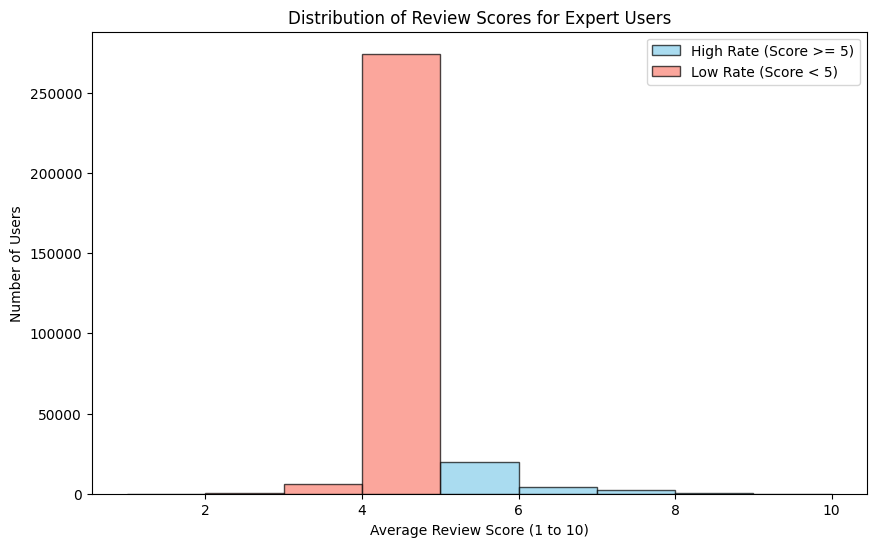

In [18]:
# Plot histograms for high and low review scores in one plot with separate bins
plt.figure(figsize=(10, 6))

# High rate scores (greater than or equal to 5)
plt.hist(expert_users_high_rate['avg_review_score'], 
         bins=[5, 6, 7, 8, 9, 10], color='skyblue', 
         alpha=0.7, label='High Rate (Score >= 5)', 
         edgecolor='black', density=False)

# Low rate scores (less than 5)
plt.hist(expert_users_low_rating['avg_review_score'], 
         bins=[1, 2, 3, 4, 5], color='salmon', 
         alpha=0.7, label='Low Rate (Score < 5)', 
         edgecolor='black', density=False)

# Add titles and labels
plt.title('Distribution of Review Scores for Expert Users')
plt.xlabel('Average Review Score (1 to 10)')
plt.ylabel('Number of Users')
plt.legend()

# Show plot
plt.show()

In [19]:
master_users = grouped_df[grouped_df['experience_level'] == 'Master']

master_users_high_rate= master_users[(master_users['avg_review_score'] > 5) & (master_users['weighted_vote_score'] != 0)]
master_users_low_rating = master_users[master_users['avg_review_score'] < 5]

# master_users_recommend.shape

print('total master users: ', master_users.shape[0])
print('master users that gave high rate : ',master_users_high_rate.shape[0])
print('master users that gave low rate : ',master_users_low_rating.shape[0])

# Calculate percentages
high_rate_percentage = round((master_users_high_rate.shape[0] / master_users.shape[0]) * 100, 0)
low_rate_percentage = round((master_users_low_rating.shape[0] / master_users.shape[0]) * 100, 0)

# Print percentages
print('Percentage of master users that gave high rate:', high_rate_percentage, '%')
print('Percentage of master users that gave low rate:', low_rate_percentage, '%')
master_users_high_rate

total master users:  584549
master users that gave high rate :  17714
master users that gave low rate :  566835
Percentage of master users that gave high rate: 3.0 %
Percentage of master users that gave low rate: 97.0 %


,author.steamid,app_id,total_playtime,avg_review_score,weighted_vote_score,total_playtime_hours,experience_level
232,76561197960269422,382310,34087.0,5.774521,0.641613,568.0,Master
511,76561197960270975,304390,32846.0,7.072405,0.785823,547.0,Master
2475,76561197960284066,48700,35436.0,5.464286,0.607143,591.0,Master
3483,76561197960294439,644930,34360.0,5.887709,0.654190,573.0,Master
3757,76561197960296978,105600,31099.0,5.116632,0.568515,518.0,Master
...,...,...,...,...,...,...,...
21297933,76561199071399621,48700,33855.0,5.250000,0.583333,564.0,Master
21321115,76561199073697272,4000,35642.0,7.490181,0.832242,594.0,Master
21354903,76561199077605897,105600,33918.0,5.058394,0.562044,565.0,Master
21357797,76561199078035652,292030,35881.0,6.341458,0.704606,598.0,Master


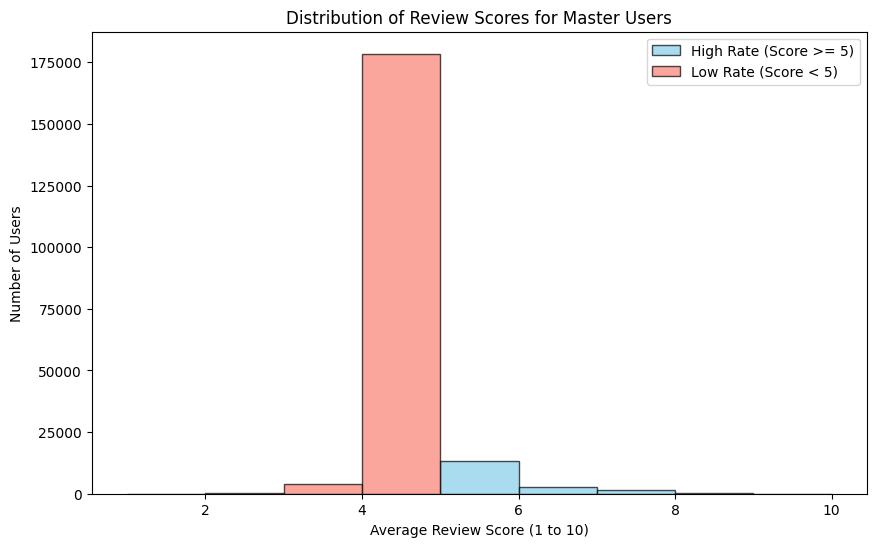

In [20]:

# Plot histograms for high and low review scores in one plot with separate bins
plt.figure(figsize=(10, 6))

# High rate scores (greater than or equal to 5)
plt.hist(master_users_high_rate['avg_review_score'], 
         bins=[5, 6, 7, 8, 9, 10], color='skyblue', 
         alpha=0.7, label='High Rate (Score >= 5)', 
         edgecolor='black', density=False)

# Low rate scores (less than 5)
plt.hist(master_users_low_rating['avg_review_score'], 
         bins=[1, 2, 3, 4, 5], color='salmon', 
         alpha=0.7, label='Low Rate (Score < 5)', 
         edgecolor='black', density=False)

# Add titles and labels
plt.title('Distribution of Review Scores for Master Users')
plt.xlabel('Average Review Score (1 to 10)')
plt.ylabel('Number of Users')
plt.legend()

# Show plot
plt.show()

The data reveals a consistent trend across all user experience levels from novice to master where only 3% of users give high ratings, while 97% provide low ratings. This uniformity suggests that experience level has minimal influence on the likelihood of giving a high or low rating. Combined with the low overall correlation (0.0157) between `total_playtime_hours` and `avg_review_score`, it’s clear that increased experience, which generally correlates with more playtime, does not significantly impact users' rating behavior. If user experience meaningfully influenced review scores, we would expect to see variations in the high rating percentage across experience levels, yet this is not observed. This consistency could imply that users across all levels share similar concerns or dissatisfaction with the content, interface, or overall experience. Consequently, the findings suggest that user engagement alone may not directly improve ratings. Instead, there may be underlying issues that require addressing to boost satisfaction across all user types.

#### 4) c)

In [21]:
# # Set the style of seaborn
# sns.set(style="whitegrid")

# # List of experience levels
# experience_levels = ['Novice', 'Intermediate', 'Advanced', 'Expert', 'Master']

# # Create a boxplot for each user experience level
# for level in experience_levels:
#     plt.figure(figsize=(10, 6))
#     sns.boxplot(x='avg_review_score', data=grouped_df[grouped_df['experience_level'] == level], palette='Set2')
#     plt.title(f'Distribution of Review Scores for {level.capitalize()} Users')
#     plt.xlabel('Average Review Score')
#     plt.ylabel('Frequency')
#     plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])  # Adjust x-ticks based on your review score scale
#     plt.grid(axis='y')
#     plt.show()

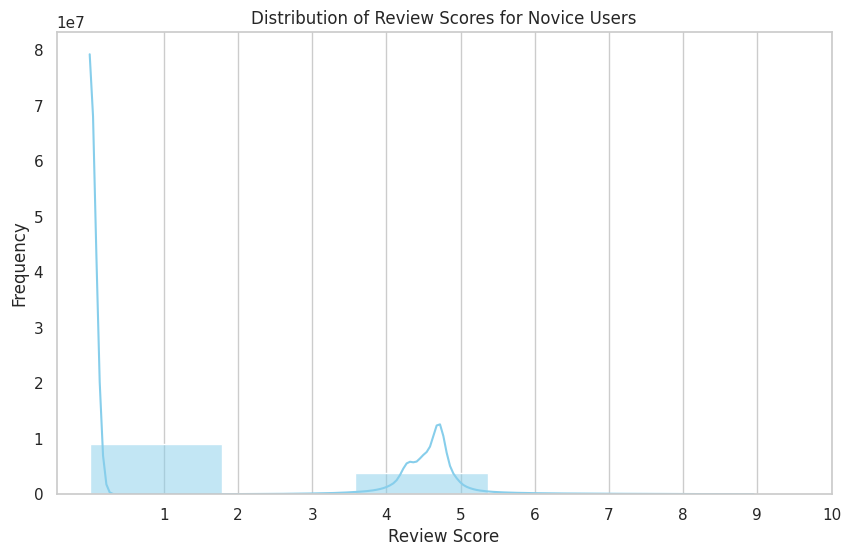

In [22]:
# Set the style of seaborn
sns.set(style="whitegrid")

# Create a histogram
plt.figure(figsize=(10, 6))
sns.histplot(novice_users['avg_review_score'], bins=5, kde=True, color='skyblue')
plt.title('Distribution of Review Scores for Novice Users')
plt.xlabel('Review Score')
plt.ylabel('Frequency')
plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])  # Ensure the x-ticks correspond to review scores
plt.grid(axis='y')
plt.show()



In [23]:
# # box plot
# plt.figure(figsize=(10, 6))
# sns.boxplot(x=novice_users['avg_review_score'], color='lightgreen')
# plt.title('Box Plot of Review Scores for Novice Users')
# plt.xlabel('Review Score')
# plt.grid(axis='y')
# plt.show()

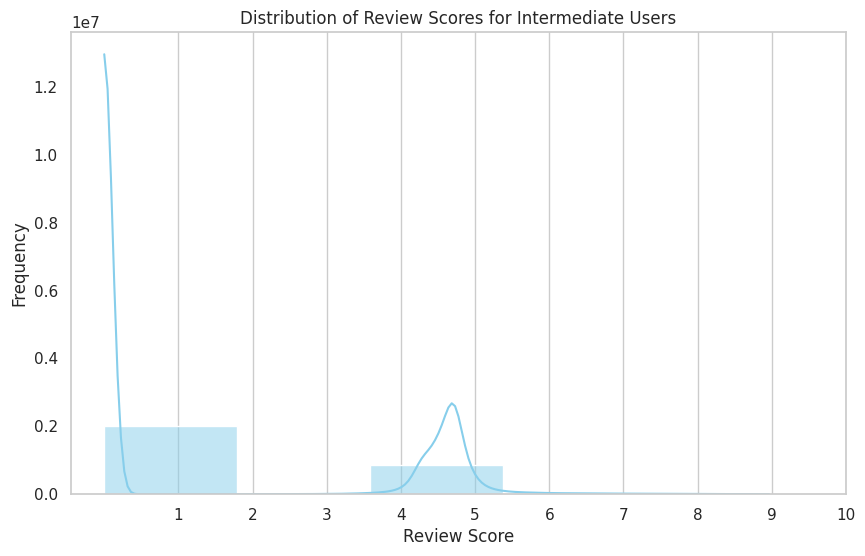

In [24]:

# Set the style of seaborn
sns.set(style="whitegrid")

# Create a histogram
plt.figure(figsize=(10, 6))
sns.histplot(intermediate_users['avg_review_score'], bins=5, kde=True, color='skyblue')
plt.title('Distribution of Review Scores for Intermediate Users')
plt.xlabel('Review Score')
plt.ylabel('Frequency')
plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])  # Ensure the x-ticks correspond to review scores
plt.grid(axis='y')
plt.show()



In [25]:
# # box plot
# plt.figure(figsize=(10, 6))
# sns.boxplot(x=intermediate_users['avg_review_score'], color='lightgreen')
# plt.title('Box Plot of Review Scores for Intermediate Users')
# plt.xlabel('Review Score')
# plt.grid(axis='y')
# plt.show()

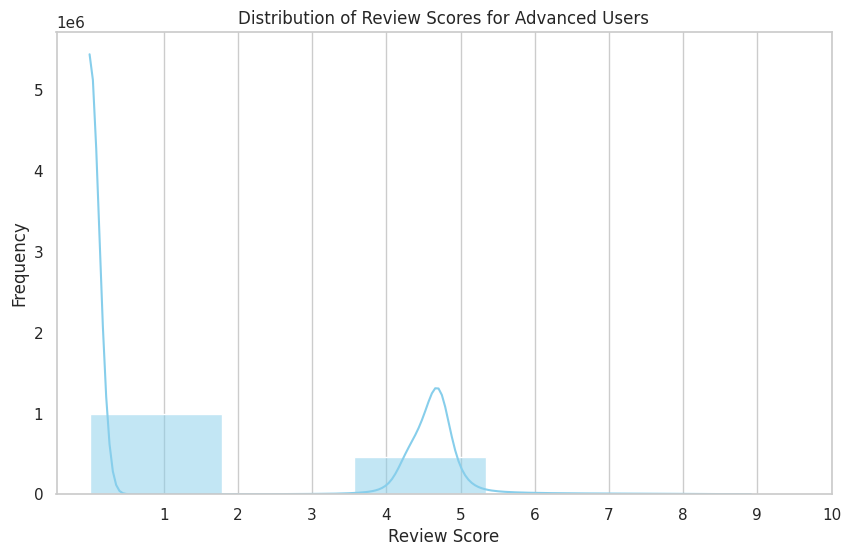

In [26]:

# Set the style of seaborn
sns.set(style="whitegrid")

# Create a histogram
plt.figure(figsize=(10, 6))
sns.histplot(advanced_users['avg_review_score'], bins=5, kde=True, color='skyblue')
plt.title('Distribution of Review Scores for Advanced Users')
plt.xlabel('Review Score')
plt.ylabel('Frequency')
plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])  # Ensure the x-ticks correspond to review scores
plt.grid(axis='y')
plt.show()



In [27]:
# # box plot
# plt.figure(figsize=(10, 6))
# sns.boxplot(x=advanced_users['avg_review_score'], color='lightgreen')
# plt.title('Box Plot of Review Scores for Advanced Users')
# plt.xlabel('Review Score')
# plt.grid(axis='y')
# plt.show()

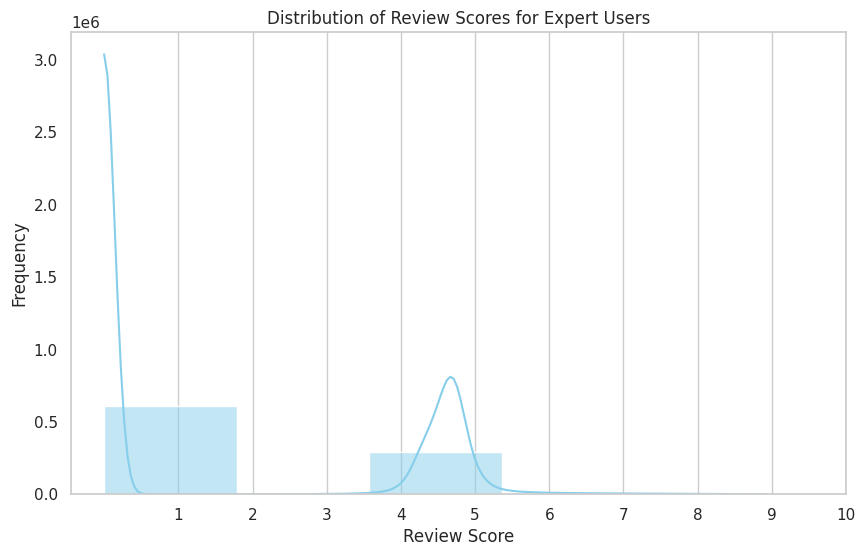

In [28]:

# Set the style of seaborn
sns.set(style="whitegrid")

# Create a histogram
plt.figure(figsize=(10, 6))
sns.histplot(expert_users['avg_review_score'], bins=5, kde=True, color='skyblue')
plt.title('Distribution of Review Scores for Expert Users')
plt.xlabel('Review Score')
plt.ylabel('Frequency')
plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])  # Ensure the x-ticks correspond to review scores
plt.grid(axis='y')
plt.show()



In [29]:
# # box plot
# plt.figure(figsize=(10, 6))
# sns.boxplot(x=expert_users['avg_review_score'], color='lightgreen')
# plt.title('Box Plot of Review Scores for Expert Users')
# plt.xlabel('Review Score')
# plt.grid(axis='y')
# plt.show()

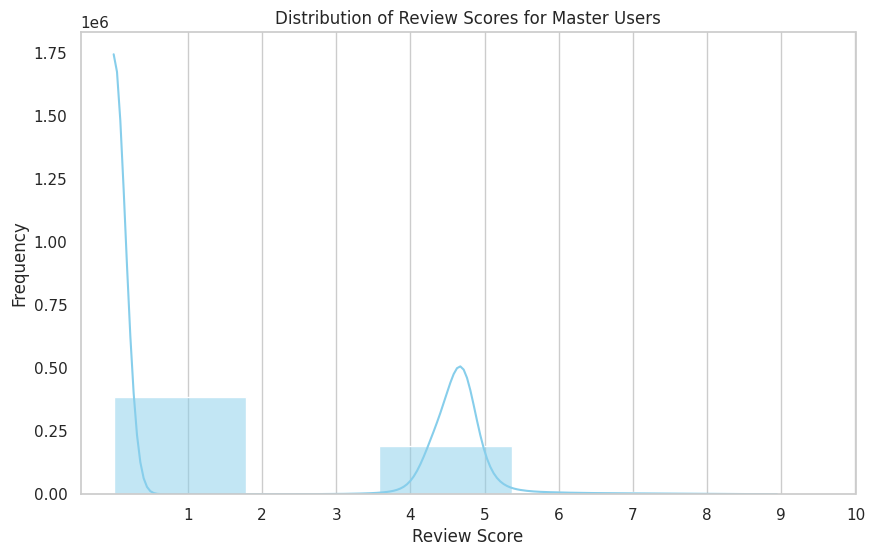

In [30]:

# Set the style of seaborn
sns.set(style="whitegrid")

# Create a histogram
plt.figure(figsize=(10, 6))
sns.histplot(master_users['avg_review_score'], bins=5, kde=True, color='skyblue')
plt.title('Distribution of Review Scores for Master Users')
plt.xlabel('Review Score')
plt.ylabel('Frequency')
plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])  # Ensure the x-ticks correspond to review scores
plt.grid(axis='y')
plt.show()



In [31]:
# # box plot
# plt.figure(figsize=(10, 6))
# sns.boxplot(x=master_users['avg_review_score'], color='lightgreen')
# plt.title('Box Plot of Review Scores for Master Users')
# plt.xlabel('Review Score')
# plt.grid(axis='y')
# plt.show()

The data shows a highly skewed distribution, with the majority of scores clustering around 1 ( 0.5 to 1.8 ) , suggesting that users at five different experience levels rated their experience poorly.

Scores between 3.5 and 5.5 indicate a smaller group of users who found the experience average or moderately acceptable. This minor peak suggests that, while most users had a negative experience, some users at different levels of experience may have found the product somewhat satisfactory but not remarkable.

As we move from novice to master experience levels, the review scores appear more normally distributed, centered around scores of 3.5 to 5.5.

The review scores across different user experience levels has minor variations in the distribution. This likely suggests that user experience level has a limited effect on how users rate the app, with no significant difference in scoring patterns between more experienced and less experienced users. 


In [32]:
# plt.figure(figsize=(12, 6))
# sns.boxplot(x='experience_level', y='avg_review_score', data=grouped_df, palette='Set2')
# plt.title('Review Score Distribution by User Experience Level')
# plt.xlabel('User Experience Level')
# plt.ylabel('Review Score')
# plt.show()

In [33]:
# from scipy.stats import ttest_1samp, ttest_ind

# # Hypothetical mean for one-sample tests
# hypothetical_mean = 5

# # One-sample t-tests
# novice_stat, novice_p = ttest_1samp(novice_users['avg_review_score'], hypothetical_mean)
# intermediate_stat, intermediate_p = ttest_1samp(intermediate_users['avg_review_score'], hypothetical_mean)
# advanced_stat, advanced_p = ttest_1samp(advanced_users['avg_review_score'], hypothetical_mean)
# expert_stat, expert_p = ttest_1samp(expert_users['avg_review_score'], hypothetical_mean)
# master_stat, master_p = ttest_1samp(master_users['avg_review_score'], hypothetical_mean)

# print("One-Sample T-Test Results:")
# print(f"Novice: t-stat = {novice_stat}, p-value = {novice_p}")
# print(f"Intermediate: t-stat = {intermediate_stat}, p-value = {intermediate_p}")
# print(f"Advanced: t-stat = {advanced_stat}, p-value = {advanced_p}")
# print(f"Expert: t-stat = {expert_stat}, p-value = {expert_p}")
# print(f"Master: t-stat = {master_stat}, p-value = {master_p}")

# # Two-sample t-tests
# print("\nTwo-Sample T-Test Results:")
# novice_intermediate_stat, novice_intermediate_p = ttest_ind(novice_users['avg_review_score'], intermediate_users['avg_review_score'])
# novice_advanced_stat, novice_advanced_p = ttest_ind(novice_users['avg_review_score'], advanced_users['avg_review_score'])
# novice_expert_stat, novice_expert_p = ttest_ind(novice_users['avg_review_score'], expert_users['avg_review_score'])
# novice_master_stat, novice_master_p = ttest_ind(novice_users['avg_review_score'], master_users['avg_review_score'])

# print(f"Novice vs Intermediate: t-stat = {novice_intermediate_stat}, p-value = {novice_intermediate_p}")
# print(f"Novice vs Advanced: t-stat = {novice_advanced_stat}, p-value = {novice_advanced_p}")
# print(f"Novice vs Expert: t-stat = {novice_expert_stat}, p-value = {novice_expert_p}")
# print(f"Novice vs Master: t-stat = {novice_master_stat}, p-value = {novice_master_p}")


In [34]:
from scipy.stats import kruskal

In [35]:
# # Separate review scores by experience level
# novice_scores = grouped_df[grouped_df['experience_level'] == 'Novice']['avg_review_score']
# intermediate_scores = grouped_df[grouped_df['experience_level'] == 'Intermediate']['avg_review_score']
# advanced_scores = grouped_df[grouped_df['experience_level'] == 'Advanced']['avg_review_score']
# expert_scores = grouped_df[grouped_df['experience_level'] == 'Expert']['avg_review_score']
# master_scores = grouped_df[grouped_df['experience_level'] == 'Master']['avg_review_score']

# # Perform Kruskal-Wallis H Test
# stat, p_value = kruskal(novice_scores, intermediate_scores, advanced_scores, expert_scores, master_scores)
# print("Kruskal-Wallis H Test")
# print("Statistic:", stat)
# print("P-value:", p_value)

# # Interpretation
# if p_value < 0.05:
#     print("There is a statistically significant difference in review score distributions across user experience levels.")
# else:
#     print("There is no statistically significant difference in review score distributions across user experience levels.")

# Define the sample size per group
sample_size = 1000  # Adjust this based on the size of your dataset and needs

# Sample each experience level group separately
novice_scores = grouped_df[grouped_df['experience_level'] == 'Novice']['avg_review_score'].sample(n=sample_size, random_state=42)
intermediate_scores = grouped_df[grouped_df['experience_level'] == 'Intermediate']['avg_review_score'].sample(n=sample_size, random_state=42)
advanced_scores = grouped_df[grouped_df['experience_level'] == 'Advanced']['avg_review_score'].sample(n=sample_size, random_state=42)
expert_scores = grouped_df[grouped_df['experience_level'] == 'Expert']['avg_review_score'].sample(n=sample_size, random_state=42)
master_scores = grouped_df[grouped_df['experience_level'] == 'Master']['avg_review_score'].sample(n=sample_size, random_state=42)

# Perform Kruskal-Wallis H Test
stat, p_value = kruskal(novice_scores, intermediate_scores, advanced_scores, expert_scores, master_scores)
print("Kruskal-Wallis H Test")
print("Statistic:", stat)
print("P-value:", p_value)

# Interpretation
if p_value < 0.05:
    print("There is a statistically significant difference in review score distributions across user experience levels.")
else:
    print("There is no statistically significant difference in review score distributions across user experience levels.")


Kruskal-Wallis H Test
Statistic: 5.680734692772416
P-value: 0.22429361117810034
There is no statistically significant difference in review score distributions across user experience levels.


H₀: The review score distributions are the same across all user experience levels.
H₁: The review score distributions differ across at least one user experience level.

The results of the Kruskal-Wallis H Test indicate that there is no statistically significant difference in review score distributions across user experience levels, with a test statistic of 5.68 and a p-value of 0.224. Since the p-value exceeds the common significance threshold of 0.05, we fail to reject the null hypothesis, which posits that the review scores among novice, intermediate, advanced, expert, and master users are similar. This finding suggests that user experience level does not meaningfully influence the ratings given by users, implying that regardless of their experience, all user categories tend to provide similar review scores.

In [ ]:
# from scipy import stats
# import pandas as pd
# import statsmodels.api as sm
# from statsmodels.formula.api import ols
# from statsmodels.stats.multicomp import pairwise_tukeyhsd


# # Step 1: ANOVA
# anova_model = ols('avg_review_score ~ experience_level', data=grouped_df).fit()
# anova_table = sm.stats.anova_lm(anova_model, typ=2)

# print("ANOVA Results:")
# print(anova_table)

# # Step 2: Post-hoc Test if ANOVA is significant
# if anova_table["PR(>F)"][0] < 0.05:
#     tukey_result = pairwise_tukeyhsd(endog=grouped_df['avg_review_score'], groups=grouped_Df['experience_level'], alpha=0.05)
#     print("\nPost-hoc Tukey HSD Test Results:")
#     print(tukey_result)
# else:
#     print("\nNo significant differences found between experience levels based on ANOVA.")


#### 4) d)

The results of our analysis indicate that there is no statistically significant difference in review score distributions across user experience levels, as demonstrated by the Kruskal-Wallis H Test, which yielded a test statistic of 5.68 and a p-value of 0.224. This suggests that users, regardless of their familiarity with the app, tend to rate it similarly, pointing towards a uniform satisfaction or dissatisfaction across experience levels. Additionally, the weak positive correlation of 0.01 between total playtime hours and average review scores implies that the time spent on the app does not significantly affect user ratings. Potential explanations for these trends include the influence of external factors such as app features or support, low variability in ratings due to widespread dissatisfaction, and similar user expectations regardless of experience level. Overall, these insights suggest that while users engage with the app differently, their experiences and ratings may be shaped more by broader issues affecting all users than by individual experience levels.

Several factors could explain why users who spend more time on the app may give higher or lower ratings. First, increased engagement often correlates with greater satisfaction; users who find the app enjoyable may rate it positively, while prolonged usage without satisfaction could lead to frustration and lower ratings. Additionally, users who explore various features may encounter bugs or limitations that negatively impact their experience. The learning curve also plays a role, as new users might struggle initially, affecting their ratings despite high playtime, whereas experienced users may rate it more favorably after mastering its functionalities. Content consumption is another key factor; users who engage with compelling content are likely to provide higher ratings, while unengaging content may lead to dissatisfaction. Furthermore, social interactions within the app can enhance user experience, with positive interactions boosting ratings and negative ones diminishing them. Finally, individual user demographics and expectations can influence both the time spent on the app and subsequent ratings, making it essential for developers to consider these factors in understanding user behavior and improving the app.

Making the review score based on sentiment analysis might give us a better understanding of rather than using the recommended flag with the weighted_vote_score to calculate the review_score.